# To what extent can electronic health record (EHR) data, specifically demographics, admission details, and medication regimens, be used to predict early (<30-day) hospital readmission for diabetic patients using supervised machine learning algorithms?

## (Replication of paper https://pmc.ncbi.nlm.nih.gov/articles/PMC12085305/)

#### Requirements to run this notebook
Requirements are added to the zipped folder as well as the csv file needed for this notebook.

In [186]:
!pip freeze > exact_requirements.txt

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Python(78878) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


# Part 1. Data preparation

## Data loading and exploration

In [131]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier 
from sklearn.neural_network import MLPClassifier

# pipeline 
from sklearn.pipeline import Pipeline

# shap analysis
import shap

# evaluation
from sklearn.metrics import auc, roc_curve, accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, mean_squared_error, root_mean_squared_error, f1_score, roc_auc_score, precision_recall_curve, average_precision_score

from sklearn.model_selection import cross_val_score

# hyperparameter searching 
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold

# statistical tests
from scipy.stats import wilcoxon


In [132]:
! pip install xgboost

Python(78809) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [133]:
! pip install shap

Python(78810) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [134]:
# Loading
diabetic_df = pd.read_csv('diabetic_data.csv')
type(diabetic_df)

pandas.core.frame.DataFrame

In [135]:
# Exploration 
diabetic_df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [136]:
diabetic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

## Data cleaning

1. Working with missing values, dropping columns/rows and checking data types
2. Check for outliers

### 1. Working with missing values, dropping columns/rows, mean substitution and checking data types

In [137]:
# Replace '?' with NaN across the entire DataFrame
diabetic_df.replace('?', np.nan, inplace=True)
diabetic_df


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [138]:
diabetic_df.isna().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

#### Columns that need cleaning due to missing values:
-weight (?)

-payer_code(?)

-medical_specialty (?)

-diag_1 (?)

-diag_2 (?)

-diag_3 (?)

-race (?)

-admission_type_id ('6' as '6' signifies NULL, '8' as 8 signifies 'Not Mapped', '5' as '5' signifies 'Not Available')

-discharge diposition_di ('18', '25', '26' as they are mapped as 'NULL', 'Not Mapped', 'Unknown/invalid')

-admission_source_id ('9', '17', '21' as they are mapped as 'NULL', 'Not Mapped', 'Unknown/Invalid')



max_glu_serum and A1Cresult have no missing values, None means they were not measured.

#### Dropping columns

-weight, as it is not critical and mostly empty

-payer_code, as it is not important and empty

-all individual drugs columns

In [139]:
diabetic_df.drop(columns = ['payer_code', 'weight'], inplace=True)

In [140]:
diabetic_df.dtypes
# To convert
#df['my_column'] = df['my_column'].astype(int)

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride                 object
acetohexamide               object
glipizide           

In [141]:
diabetic_df.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride                 object
acetohexamide               object
glipizide           

#### Standardising values in columns

There are certain columns that need to be changed before splitting the data to train/test subsets otherwise there will be issues with one-hot encoding and models performance:

-age: I need to get rid of the range 

-readmitted (future 'y'): needs to be changed to binary 0 and 1

-change and diabetesMed: need to be changed to binary where No -> 0, the rest -> 1

-all columns with medications: need to be transformed into binary where No -> 0 and the rest -> 1 -> were later dropped all together to improve performance

-Combining diagnosis in groups

-Combining medical specialties 

-Changing 'None' to 'Not Tested' in 'max_glu_serum' and 'A1Cresult'



    

In [142]:
# Age

def get_midpoint(age):
    a, b = age.split('-')
    new_age = (int(a)+int(b))/2
    return new_age
    

diabetic_df['age'] = diabetic_df['age'].str.replace('[', '', regex=False).str.replace(']', '', regex=False).str.replace('(', '', regex=False).str.replace(')', '', regex=False)

diabetic_df['age'] = diabetic_df.apply(lambda x: get_midpoint(x['age']), axis=1)

In [143]:
# Change and diabetesMed
diabetic_df['change'] = diabetic_df['change'].replace({'No': 0, 'Ch': 1}).astype(int)
diabetic_df['diabetesMed'] = diabetic_df['diabetesMed'].replace({'No': 0, 'Yes': 1}).astype(int)


# Changing readmitted - future 'y_train/y_test' - to binary
diabetic_df['readmitted'] = diabetic_df['readmitted'].replace({'>30': 0, 'NO': 0, '<30': 1}).astype(int)

print(diabetic_df.head())

   encounter_id  patient_nbr             race  gender   age  \
0       2278392      8222157        Caucasian  Female   5.0   
1        149190     55629189        Caucasian  Female  15.0   
2         64410     86047875  AfricanAmerican  Female  25.0   
3        500364     82442376        Caucasian    Male  35.0   
4         16680     42519267        Caucasian    Male  45.0   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital         medical_specialty  ...  citoglipton  insulin  \
0                 1  Pediatrics-Endocrinology  ...           No       No   
1                 3                       

/var/folders/x2/t2g80_cn13n9xpg_l56hwz600000gn/T/ipykernel_68976/4035942516.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  diabetic_df['change'] = diabetic_df['change'].replace({'No': 0, 'Ch': 1}).astype(int)
/var/folders/x2/t2g80_cn13n9xpg_l56hwz600000gn/T/ipykernel_68976/4035942516.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  diabetic_df['diabetesMed'] = diabetic_df['diabetesMed'].replace({'No': 0, 'Yes': 1}).astype(int)
/var/folders/x2/t2g80_cn13n9xpg_l56hwz600000gn/T/ipykernel_68976/4035942516.py:7: FutureWarning: 

In [144]:
# All med columns transformation
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 
    'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 
    'miglitol', 'insulin', 'glyburide-metformin', 'tolazamide', 
    'metformin-pioglitazone', 'metformin-rosiglitazone', 
    'glipizide-metformin', 'troglitazone', 'tolbutamide', 'acetohexamide',
'examide', 'citoglipton']

for col in medication_cols:
    diabetic_df[col] = diabetic_df[col].map({'No': 0, 'Steady': 1, 'Up': 1, 'Down': 1})

In [145]:
# Combining diagnosis and medical specialties 
def group_icd9(code):
    code = str(code)
    if code.startswith('250'): return 'Diabetes'
    elif code.startswith('390') or code.startswith('410') or code.startswith('428'): return 'Circulatory'
    elif code.startswith('460') or code.startswith('786'): return 'Respiratory'
    elif code == 'Missing': return 'Missing'
    else: return 'Other'
for col in ['diag_1', 'diag_2', 'diag_3']:
    diabetic_df[col] = diabetic_df[col].apply(lambda x: group_icd9(x))

def specialty(spec):
    if spec in ['InternalMedicine', 'Cardiology', 'Family/GeneralPractice']: return spec
    else: return 'Other'
diabetic_df['medical_specialty'] = diabetic_df['medical_specialty'].apply(lambda x: specialty(x))

diabetic_df['max_glu_serum'] = diabetic_df['max_glu_serum'].replace(np.nan, 'Not Tested')
diabetic_df['A1Cresult'] = diabetic_df['A1Cresult'].replace(np.nan, 'Not Tested')
categorical_columns = [
    'max_glu_serum',
    'A1Cresult',
    'diag_1',
    'diag_2',
    'diag_3',
]

As part of feature engineering, I also think it is important to aggregate some results not by encounter (patient stays) but by patient to improve model performance.

In [146]:
# Aggregating by patient (feature engineering)

# Sort chronologically by patient and then by encounter order
# This ensures that history is built forward in time
diabetic_df = diabetic_df.sort_values(by=['patient_nbr', 'encounter_id'])

features_to_aggregate = [
    'num_medications', 
    'num_lab_procedures', 
    'number_inpatient', 
    'num_procedures', 
    'time_in_hospital', 
    'diabetesMed'
]

# groupby with cumsum and shift to prevent data leakage
# .cumsum() calculates the running total up to and including the current row
# .shift(1) moves the results down so current row only sees previous data
# .fillna(0) handles the first visit for each patient (where there is no history)
for col in features_to_aggregate:
    new_col_name = 'prior_' + col
    diabetic_df[new_col_name] = (
        diabetic_df.groupby('patient_nbr')[col]
        .cumsum()
        .groupby(diabetic_df['patient_nbr'])
        .shift(1)
        .fillna(0)
    )

# renaming
diabetic_df.rename(columns={
    'prior_num_medications': 'prior_total_meds',
    'prior_num_lab_procedures': 'prior_total_labs',
    'prior_number_inpatient': 'prior_inpatient_visits',
    'prior_num_procedures': 'prior_total_procedures',
    'prior_time_in_hospital': 'prior_days_in_hospital',
    'prior_diabetesMed': 'prior_diabetes_med_count'
}, inplace=True)


In [147]:
diabetic_df.sample(5).T

,67112,53012,74199,25570,96470
encounter_id,188045934,156034104,220792614,85275942,376037114
patient_nbr,62051697,24186294,100659996,3446793,108845919
race,Caucasian,AfricanAmerican,AfricanAmerican,Caucasian,Caucasian
gender,Female,Female,Male,Female,Male
age,55.0,45.0,85.0,75.0,75.0
admission_type_id,1,1,2,1,1
discharge_disposition_id,1,1,1,1,1
admission_source_id,7,7,7,7,7
time_in_hospital,3,3,4,5,10
medical_specialty,Other,InternalMedicine,Other,InternalMedicine,Other


### 2. Checking distribution and outliers in important features

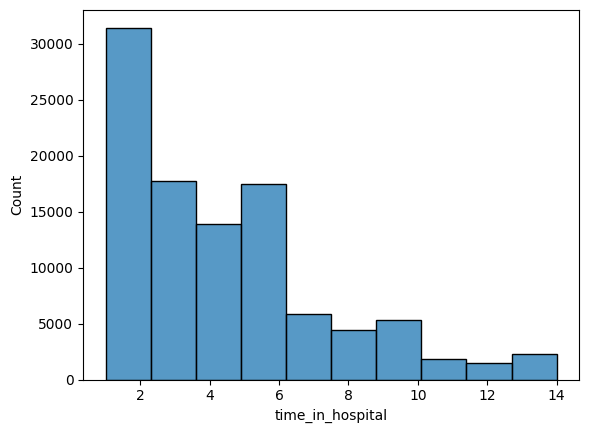

In [187]:
# Plotting histograms for 4 important numeric columns (features)
# 1. time_in_hospital histogram
sns.histplot(diabetic_df['time_in_hospital'], bins = 10, kde = False)
plt.show()

<Axes: xlabel='time_in_hospital'>

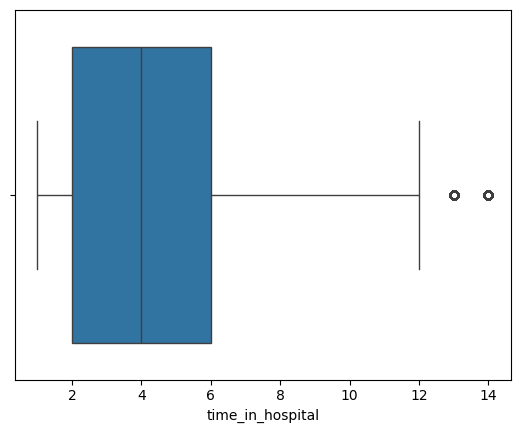

In [149]:
# time_in_hospital boxplot
sns.boxplot(x = diabetic_df['time_in_hospital'])

<Axes: xlabel='num_lab_procedures', ylabel='Count'>

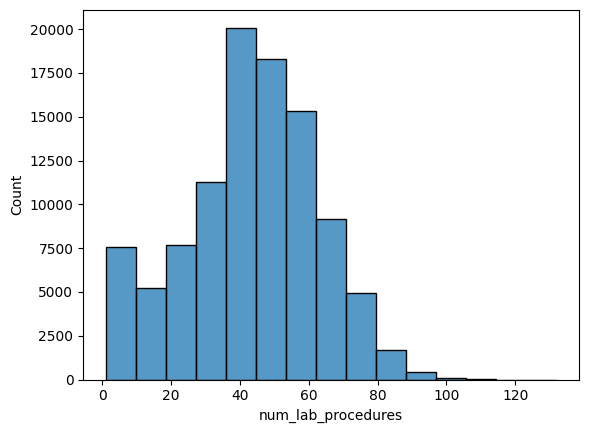

In [150]:
# 2. num_lab_procedures histogram
sns.histplot(diabetic_df['num_lab_procedures'], bins = 15, kde = False)

<Axes: xlabel='num_lab_procedures'>

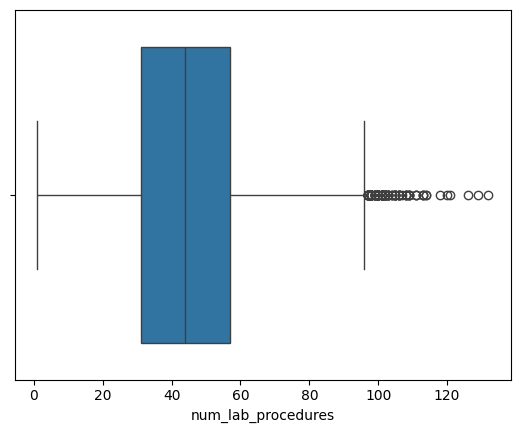

In [151]:
# num_lab_procedures boxplot
sns.boxplot(x = diabetic_df['num_lab_procedures'])

<Axes: xlabel='num_procedures', ylabel='Count'>

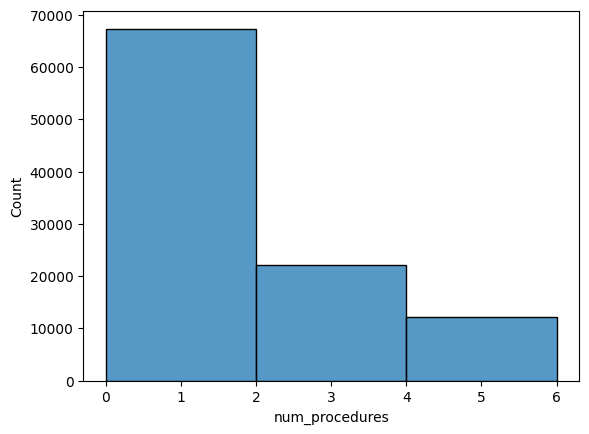

In [152]:
# 3. num_procedures histogram
sns.histplot(diabetic_df['num_procedures'], bins = 3, kde = False)

<Axes: xlabel='num_medications', ylabel='Count'>

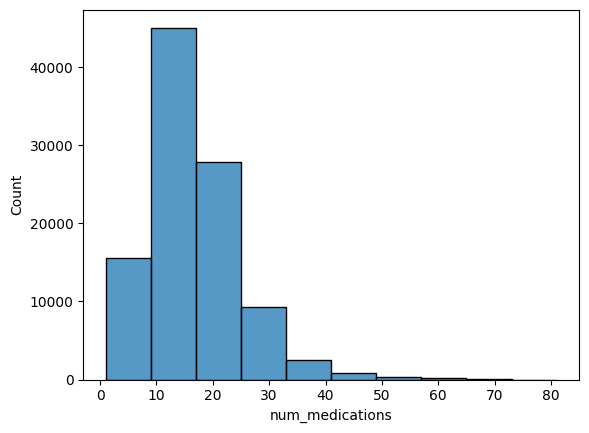

In [153]:
# 4. num_medications
sns.histplot(diabetic_df['num_medications'], bins = 10, kde = False)

<Axes: xlabel='num_medications'>

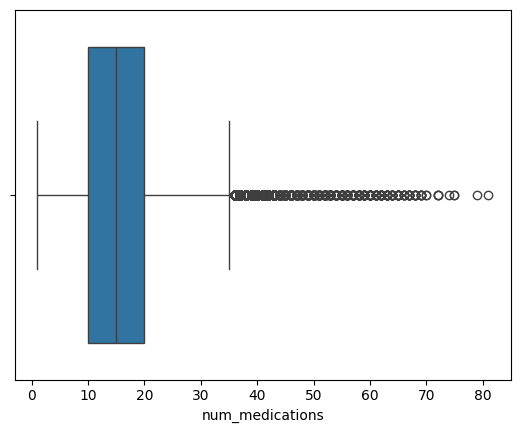

In [154]:
sns.boxplot(x = diabetic_df['num_medications'])

Theoutliers are present in 3 of the important numeric features. However, these outliers are important data points for the prediction of whether the abnormal number of lab and other procedures coupled with a prolonged hospital stay are key features in prediction hospital readmission in less than 30 days. Therefore, I proceed without removing them.

#### Correlation Heatmap

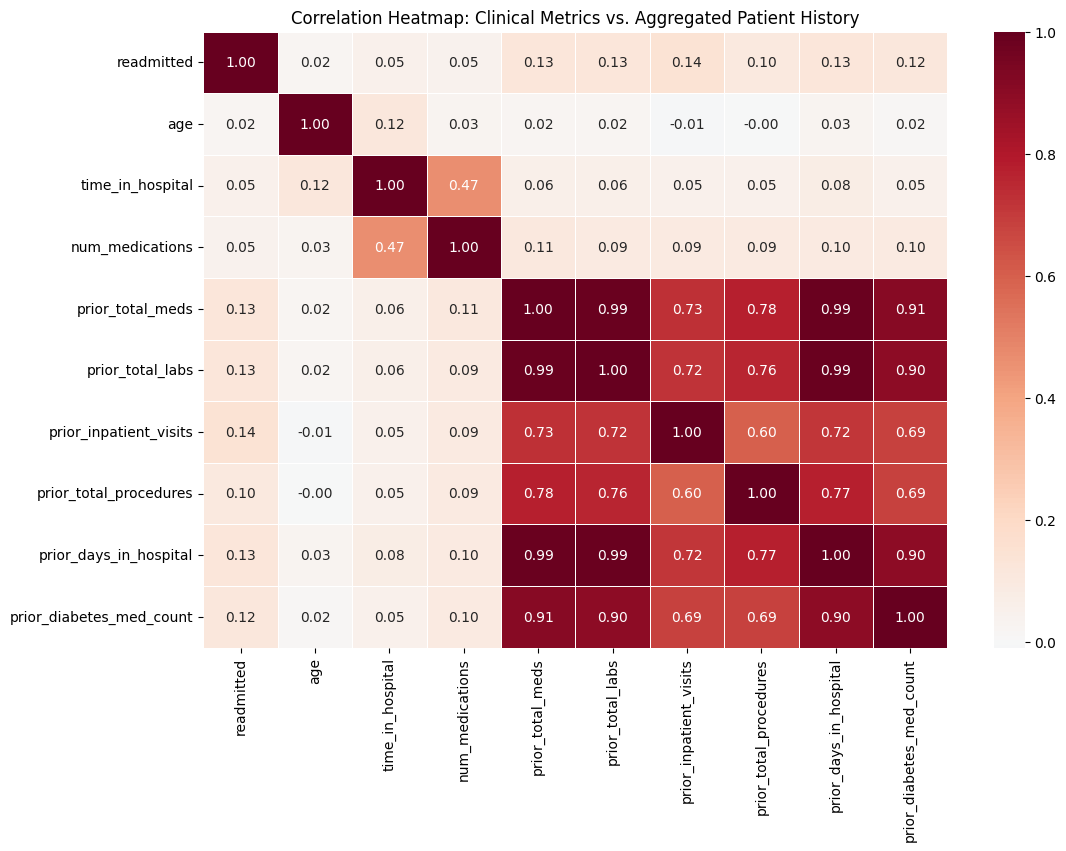

In [155]:
# Correlation 

features_of_interest = [
    'readmitted', 'age', 'time_in_hospital', 'num_medications', 
    'prior_total_meds', 'prior_total_labs', 'prior_inpatient_visits', 
    'prior_total_procedures', 'prior_days_in_hospital', 'prior_diabetes_med_count'
]

# Calculate the correlation matrix
# Using the Spearman method can better capture non-linear relationships common in EHR data
corr_matrix = diabetic_df[features_of_interest].corr(method='spearman')

# Generate the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap: Clinical Metrics vs. Aggregated Patient History')
plt.show()

A key finding is that the 'prior' historical features, i.e. prior_inpatient_visits (0.14), prior_total_meds (0.13), and prior_days_in_hospital (0.13) show a stronger correlation with the readmitted target than single-encounter variables such as time_in_hospital (0.05) or num_medications (0.05).

There is also multicollinearity within the aggregated features, with correlations as high as 0.99 between total medications and laboratory procedures. This justifies the selection of ensemble frameworks like XGBoost.

#### Distribution of key numerical columns

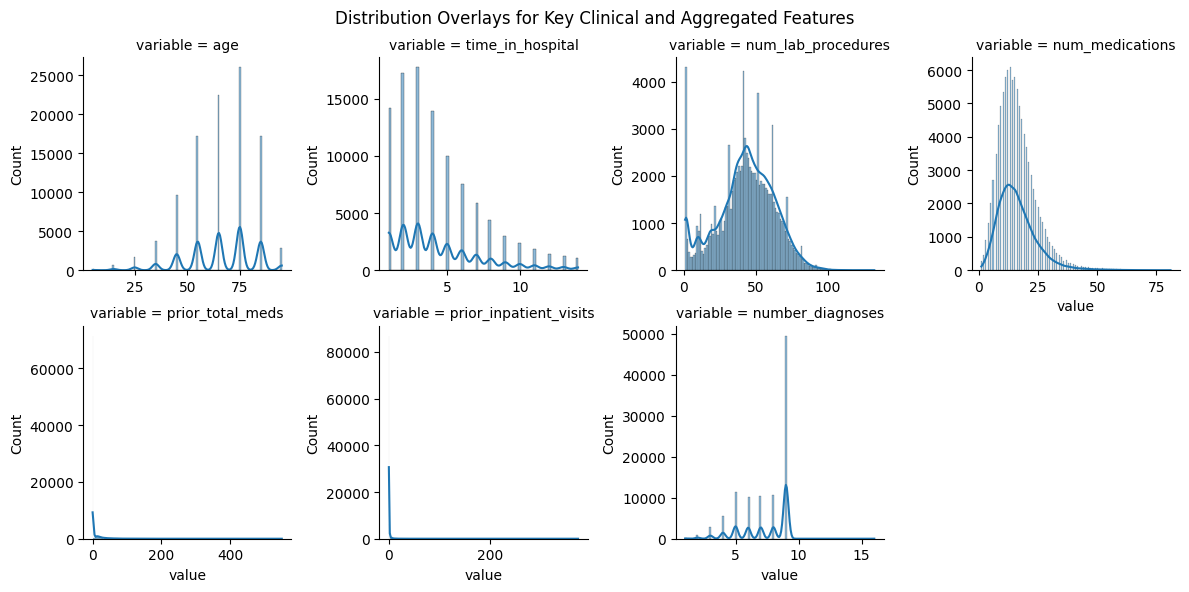

In [156]:
# Define the numerical features
cols_to_plot = [
    'age', 'time_in_hospital', 'num_lab_procedures', 'num_medications', 
    'prior_total_meds', 'prior_inpatient_visits', 'number_diagnoses'
]

# 'Melt' the data so all values are in one column and variable names in another
df_melted = diabetic_df[cols_to_plot].melt()

# Create a grid where each column gets its own subplot
g = sns.FacetGrid(df_melted, col="variable", col_wrap=4, sharex=False, sharey=False)
g.map(sns.histplot, "value", kde=True)

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Distribution Overlays for Key Clinical and Aggregated Features')
plt.show()

time_in_hospital, num_lab_procedures, and num_medications show right-skewness and the presence of outliers, which confirm the need to use of StandardScaler to normalize the data for optimal model performance. 

The age distribution shows various peaks corresponding to the midpoints of original ranges, confirming that the dataset is composed of an elderly population.

The engineered features prior_total_meds and prior_inpatient_visits show concentrations at zero, showing the data sparsity challenge common (as evident from reviewed literature) in electronic health records (EHR) where many patients have no prior hospital history documented within the specific study period. 

number_diagnoses plot has peaks, especially at the value of nine, which might be suggesting some administrative practices prevalent during the 1999–2008 timeframe.

# Part 2. Train and Test Splitting

In [157]:
# X is everything except encounter_id, patient_nbr and the target column
columns_to_drop = ['encounter_id', 'patient_nbr', 'readmitted', 'glimepiride-pioglitazone']  + medication_cols

X = diabetic_df.drop(columns_to_drop, axis=1)

# y is only the target column
y = diabetic_df['readmitted']

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42 # To make the split reproducible
)
type(X_train)

pandas.core.frame.DataFrame

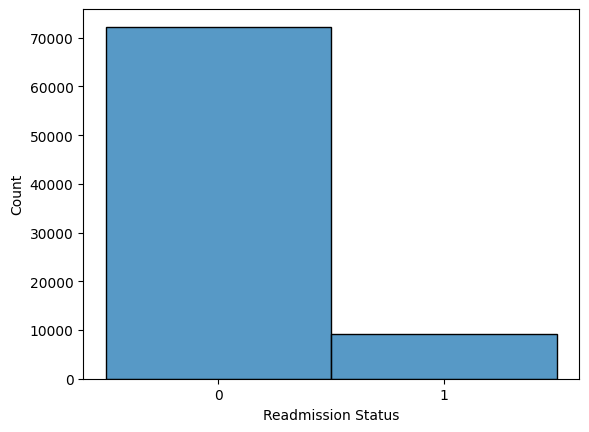

In [158]:
# Showing class imbalance in target train subset of data
sns.histplot(y_train, discrete=True, kde=False)

plt.xticks([0, 1])
plt.xlabel('Readmission Status')
plt.ylabel('Count')
plt.show()

# Part 3. Create Transformation, Training and Evaluation Pipelines

1. One-hot enconding for categorical data
2. Scaling for numeric data
3. Mode imputation for NaNs as they are mostly categorical

Some clues from paper:  "combined clinical domain knowledge and SHAP value analyses, identifying the most influential variables contributing significantly to prediction accuracy [14]."


In [159]:
categorical_columns = [
    'max_glu_serum',
    'A1Cresult',
]


In [160]:
aggregated_columns = [
    'prior_total_meds', 
    'prior_total_labs', 
    'prior_inpatient_visits', 
    'prior_total_procedures', 
    'prior_days_in_hospital', 
    'prior_diabetes_med_count'
]

In [161]:
# These are the columns that need scaling
numerical_features = ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency','number_inpatient', 'number_diagnoses'] + aggregated_columns
# These are the columns that need mode imputation
mode_imputation_columns = ['race', 'gender', 'medical_specialty', 'diag_1',
    'diag_2',
    'diag_3']

In [162]:
# Pipeline for imputation and encoding of the columns where imputation was applied
impute_then_encode = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# OneHotEncoder for other categorical columns
just_encode = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [163]:
# [] - holds the list of transformations, () holds: (name for this transformation, transformer, columns formatted as [number 1, number 2])
# One-hot encoder and scaler
trf1 = ColumnTransformer(
    transformers=[
        ('encoding_with_imputation', impute_then_encode, mode_imputation_columns),
        ('all_categorical', just_encode, categorical_columns),
        ('numerical_scaling', StandardScaler(), numerical_features),
    ], remainder = 'passthrough')

## Pipeline: Logisitic Regression

In [164]:
trf_logistic = LogisticRegression(max_iter=1_000, class_weight='balanced', random_state=42)

In [165]:
pipe_logistic = Pipeline([
    ('trf1',trf1),
    ('trf_logistic', trf_logistic)
]).set_output(transform='pandas')
# Train the pipeline 
pipe_logistic.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('trf1', ...), ('trf_logistic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoding_with_imputation', ...), ('all_categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If

In [166]:
# Evaluation Logistic Regression
y_pred = pipe_logistic.predict(X_test) 
print(f'Accuracy score: {accuracy_score(y_test, y_pred)}')
print(f'Precision score: {precision_score(y_test, y_pred)}')
print(f'Recall score: {recall_score(y_test, y_pred)}')

# Mean squared error
print(f'Mean squared error: {mean_squared_error(y_test, y_pred)}')

# AUC-ROC
#roc_auc = roc_auc_score(y_test, y_pred)
#print(f'AUC-ROC: {roc_auc:.4f}')

# F1 score
f1 = f1_score(y_test, y_pred)
print(f'F1: {f1:.4f}')

# Cross-validation
print(f'Cross-validation: {cross_val_score(pipe_logistic, X_train, y_train, cv=5, scoring="accuracy").mean()}')

Accuracy score: 0.6735776751498477
Precision score: 0.16940543770540784
Recall score: 0.5112714156898106
Mean squared error: 0.3264223248501523
F1: 0.2545
Cross-validation: 0.6675060142432361


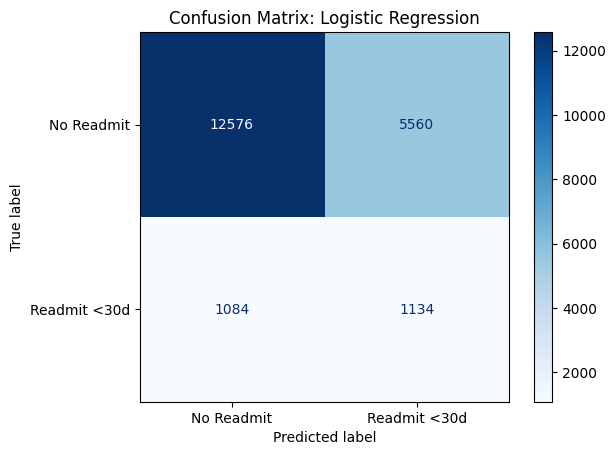

In [167]:
# Logistic Regression: confusion matrix
cm_logistic = confusion_matrix(y_test, y_pred)

# Visualising
logistic_confusion_viz = ConfusionMatrixDisplay(confusion_matrix=cm_logistic, display_labels=['No Readmit', 'Readmit <30d'])
logistic_confusion_viz.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

## Pipeline: Random Forest

In [168]:
trf_forest = RandomForestClassifier(random_state=42, class_weight='balanced', max_depth=10, min_samples_leaf=5, min_samples_split=2, n_estimators=200)

In [169]:
pipe_forest = Pipeline([
    ('trf1', trf1),
    ('trf_forest', trf_forest)
]).set_output(transform='pandas')

# Train the pipeline
pipe_forest.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('trf1', ...), ('trf_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoding_with_imputation', ...), ('all_categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If t

In [170]:
# Evaluation Random Forest

y_pred_hard = pipe_forest.predict(X_test)
y_pred = pipe_forest.predict_proba(X_test)[:, 1] 

# Accuracy, precision, recall
y_pred_threshold = [1 if x > 0.35 else 0 for x in y_pred] # for confusion matrix
print(f'Accuracy score: {accuracy_score(y_test, y_pred_threshold)}')
print(f'Precision score: {precision_score(y_test, y_pred_threshold)}')
print(f'Recall score: {recall_score(y_test, y_pred_threshold)}')

# Mean squared error
print(f'Mean squared error: {mean_squared_error(y_test, y_pred)}')

# AUC-ROC
roc_auc = roc_auc_score(y_test, y_pred)
print(f'AUC-ROC: {roc_auc:.4f}')

# F1 score
f1 = f1_score(y_test, y_pred_threshold)
print(f'F1: {f1:.4f}')

# Cross-validation
print(f'Cross-validation: {cross_val_score(pipe_forest, X_train, y_train, cv=5, scoring="accuracy").mean()}')


Accuracy score: 0.283924535717795
Precision score: 0.12328516553868667
Recall score: 0.9116321009918846
Mean squared error: 0.21129114468923038
AUC-ROC: 0.6644
F1: 0.2172
Cross-validation: 0.7053381851071512


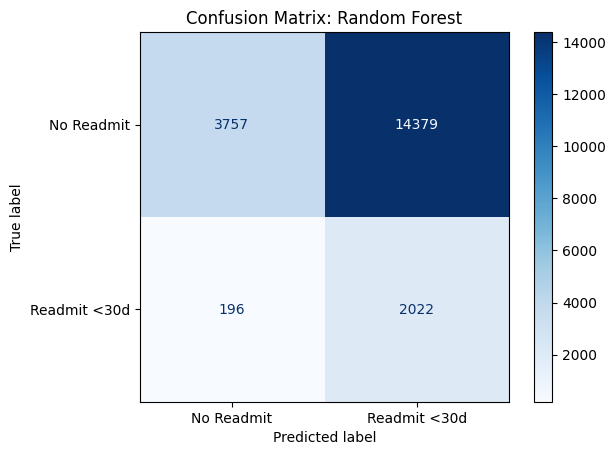

In [171]:
# Random Forest: confusion matrix 
cm_forest = confusion_matrix(y_test, y_pred_threshold)

# Visualising
forest_confusion_viz = ConfusionMatrixDisplay(confusion_matrix=cm_forest, display_labels=['No Readmit', 'Readmit <30d'])
forest_confusion_viz.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: Random Forest')
plt.show()

## Pipeline: XGBoost

In [172]:
# Pickincg correct scale_pos_weight for the model (weight balancing of classes)
counts = y_train.value_counts()
ratio = counts[0]/counts[1]
print(counts)
print(ratio)

readmitted
0    72273
1     9139
Name: count, dtype: int64
7.90819564503775


In [173]:
trf_xgb = XGBClassifier(enable_categorical=True, random_state=42, scale_pos_weight=ratio, eval_metric='logloss', learning_rate=0.1, max_depth=3, n_estimators=200)


In [174]:
pipe_xgb = Pipeline([
    ('trf1', trf1),
    ('trf_xgb', trf_xgb)
]).set_output(transform='pandas')
# Train the pipeline
pipe_xgb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('trf1', ...), ('trf_xgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoding_with_imputation', ...), ('all_categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the 

In [175]:
# Evaluation
y_pred_hard = pipe_xgb.predict(X_test)
y_pred = pipe_xgb.predict_proba(X_test)[:, 1] # predicting probabilities, transposing to row 

y_pred_threshold = [1 if x > 0.35 else 0 for x in y_pred] # for confusion matrix
print(f'Accuracy score: {accuracy_score(y_test, y_pred_threshold)}')
print(f'Precision score: {precision_score(y_test, y_pred_threshold)}')
print(f'Recall score: {recall_score(y_test, y_pred_threshold)}')

# Mean squared error
print(f'Mean squared error: {mean_squared_error(y_test, y_pred)}')

# AUC-ROC
roc_auc = roc_auc_score(y_test, y_pred)
print(f'AUC-ROC: {roc_auc:.4f}')

# F1 score
f1 = f1_score(y_test, y_pred_threshold)
print(f'F1: {f1:.4f}')


Accuracy score: 0.3383610101208608
Precision score: 0.1306717446976164
Recall score: 0.8972046889089269
Mean squared error: 0.21934133768081665
AUC-ROC: 0.6798
F1: 0.2281


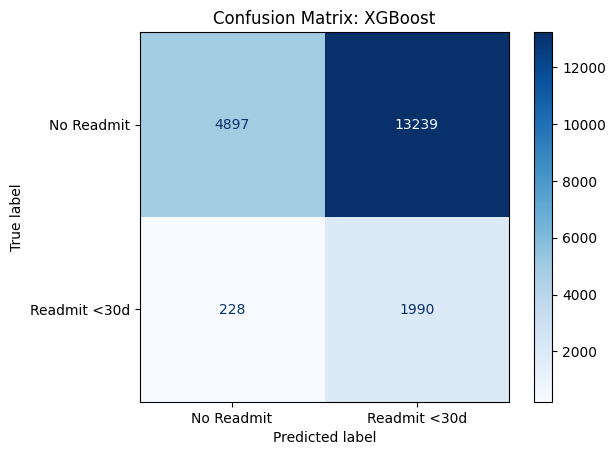

In [176]:
# XGBoost: confusion matrix 
cm_xgboost = confusion_matrix(y_test, y_pred_threshold)

# Visualising
xgb_confusion_viz = ConfusionMatrixDisplay(confusion_matrix=cm_xgboost, display_labels=['No Readmit', 'Readmit <30d'])
xgb_confusion_viz.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: XGBoost')
plt.show()

#### SHAP analysis to mirror the methodology from the paper I am replicating. SHAP is used to identify influential variables.

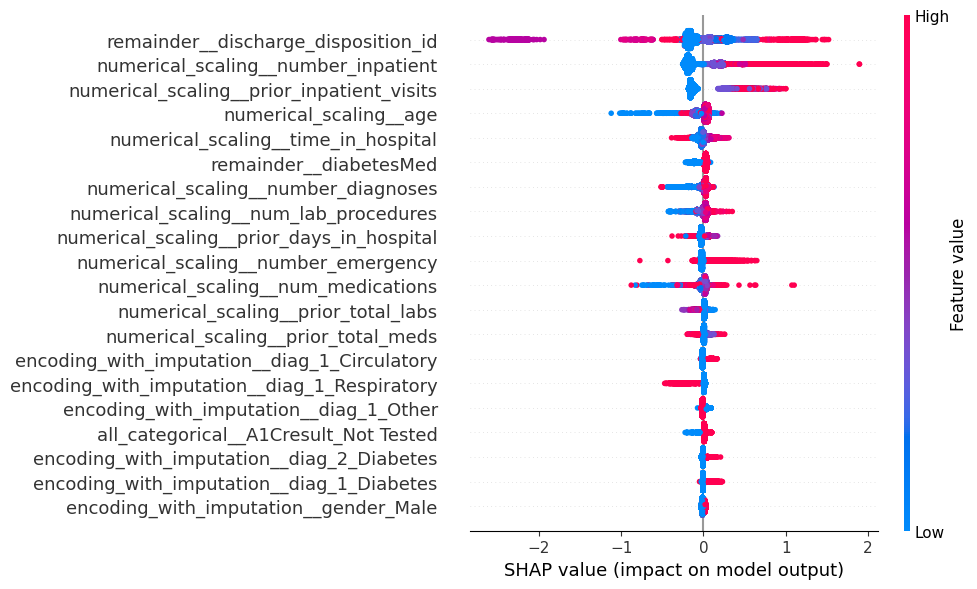

In [177]:
# Initialising the SHAP explainer 
explainer = shap.Explainer(pipe_xgb.named_steps['trf_xgb']) # or your xgb step name
shap_values = explainer(pipe_xgb.named_steps['trf1'].transform(X_test))

# Creating the plot
shap.summary_plot(shap_values, pipe_xgb.named_steps['trf1'].transform(X_test), plot_size=(10, 6), show = False)
plt.tight_layout()
plt.show()

Y axis:
the most influential feature is discharge_disposition_id, followed by number_inpatient and prior_inpatient_visits(aggregated column).

X axis: 
show the impact on the model's output. Points to the right of 0 -> increase the risk of readmission. Points to the left of 0 -> decrease the risk.


## Pipeline: DNNs (MLP in scikit-learn)

In [178]:
from sklearn.neural_network import MLPClassifier

# Defining a Deep Neural Network 
dnn = MLPClassifier(
    hidden_layer_sizes=(20,), 
    alpha=0.0001,
    activation='relu', 
    solver='adam', 
    max_iter=20,
    random_state=42
)

pipe_dnn = Pipeline([
    ('trf1', trf1),
    ('dnn', dnn)
])

pipe_dnn.fit(X_train, y_train)


# Evaluation

y_pred_hard = pipe_dnn.predict(X_test)
y_pred = pipe_dnn.predict_proba(X_test)[:, 1] # predicting probabilities, transposing to row 

# Accuracy, precision, recall
y_pred_threshold = [1 if x > 0.2 else 0 for x in y_pred] # for confusion matrix 
print(f'Accuracy score: {accuracy_score(y_test, y_pred_threshold)}')
print(f'Precision score: {precision_score(y_test, y_pred_threshold)}')
print(f'Recall score: {recall_score(y_test, y_pred_threshold)}')

# Mean squared error
print(f'Mean squared error: {mean_squared_error(y_test, y_pred)}')

# AUC-ROC
roc_auc = roc_auc_score(y_test, y_pred)
print(f'AUC-ROC: {roc_auc:.4f}')

# F1 score
f1 = f1_score(y_test, y_pred_threshold)
print(f'F1: {f1:.4f}')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy score: 0.8548688218531983
Precision score: 0.2401129943502825
Recall score: 0.1532912533814247
Mean squared error: 0.09410185520051523
AUC-ROC: 0.6509
F1: 0.1871


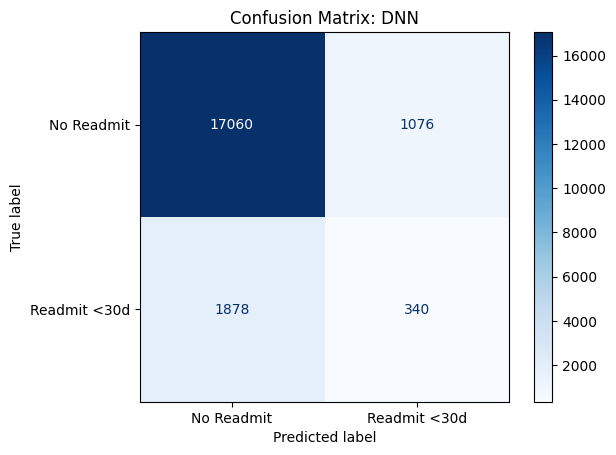

In [179]:
# DNN: confusion matrix 
cm_dnn = confusion_matrix(y_test, y_pred_threshold)

# Visualising
dnn_confusion_viz = ConfusionMatrixDisplay(confusion_matrix=cm_dnn, display_labels=['No Readmit', 'Readmit <30d'])
dnn_confusion_viz.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: DNN')
plt.show()

#### Plotting AUC-ROC curves for all models

Given the class imbalance in y in the dataset, standard accuracy is insufficient metrics. AUC-ROC offers a more objective analysis by evaluating the trade-off between True Positive Rate (recall) and False Positive Rate.

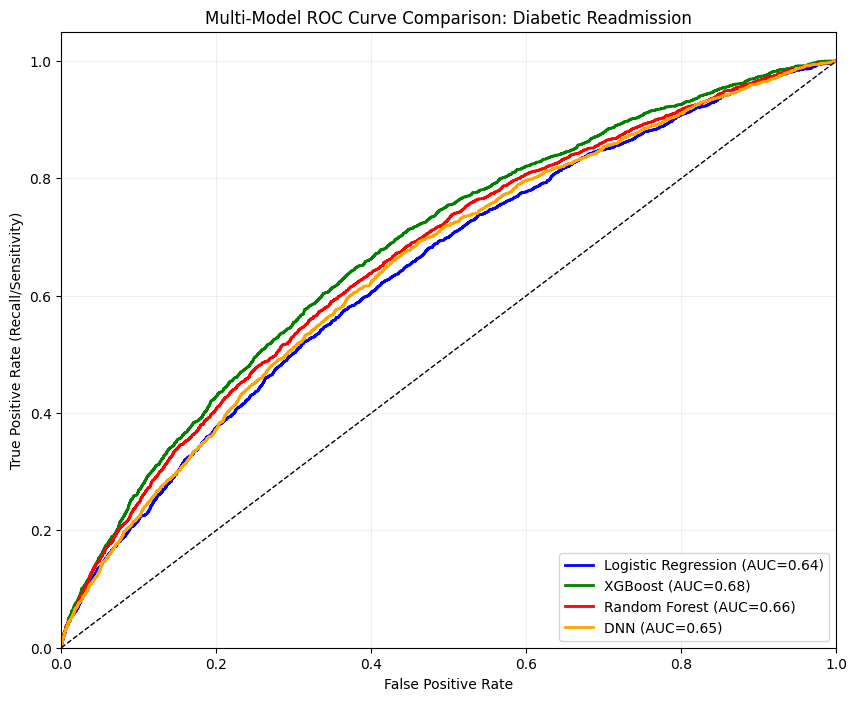

In [180]:
# Dictionary for easier iteration
models = {
    'Logistic Regression': pipe_logistic,
    'XGBoost': pipe_xgb,
    'Random Forest': pipe_forest,
    'DNN': pipe_dnn
}

plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'orange']

# Loop for probability calc and plotting
for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]

    # ROC metrics calculation
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plotting
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={roc_auc:.2f})')


# Visualising details
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--') # Diagonal baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.title('Multi-Model ROC Curve Comparison: Diabetic Readmission')

plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

    

This ROC curve comparison shows that the ensemble models, XGBoost (AUC=0.68) and Random Forest (AUC=0.66), provide better predictive performance and class separability for diabetic readmission compared to the Logistic Regression (AUC=0.64) baseline and the DNN (AUC=0.65).

#### Plotting precision-recall curves


Again, due to class imbalance standard accuracy score can be misleading. The PR curve visualizes the trade-off between the Positive Predictive Value (precision) and Sensitivity (recall) across all classification thresholds.

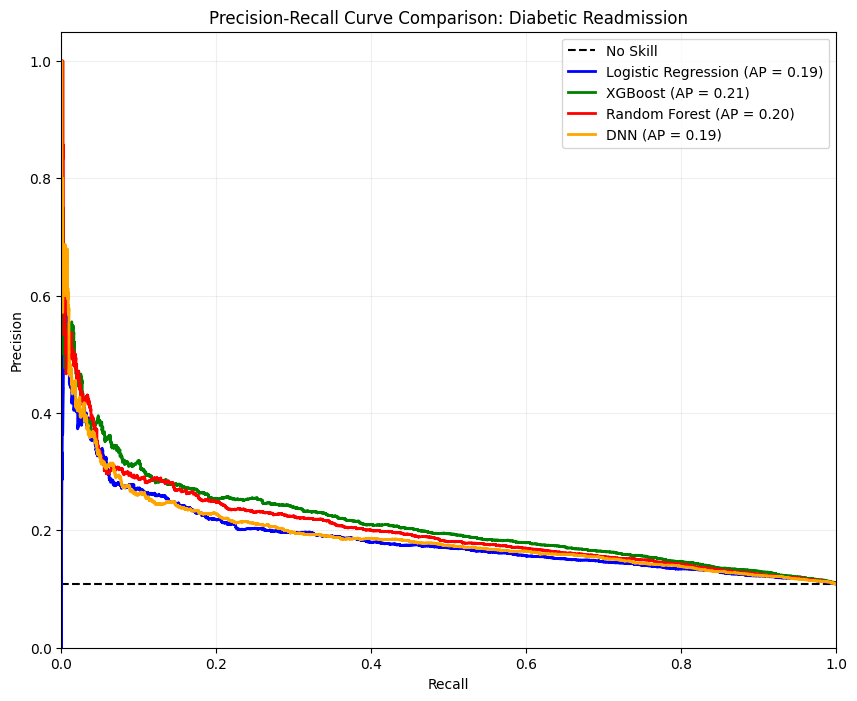

In [181]:
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'orange']

# Plot the no-skill baseline (proportion of positive cases)
no_skill = len(y_test[y_test==1]) / len(y_test)
plt.axhline(y=no_skill, color='black', linestyle='--', label='No Skill')

# Loop through models to calculate and plot
for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap_score = average_precision_score(y_test, y_prob)
    
    plt.plot(recall, precision, color=color, lw=2, 
             label=f'{name} (AP = {ap_score:.2f})')

# 4. Finalize plot aesthetics
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison: Diabetic Readmission')
plt.legend(loc='upper right')
plt.grid(alpha=0.2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()

As recall moves toward 1.0 which means catching all readmitted patients, the precision of all models drops toward the baseline. This demonstrates the cost of high sensitivity as to catch every readmitted patient, the hospital must accept a high number of false-positive results - patients who were not actually readmitted although the model flagged as if they would be readmitted.

# Part 4. Hyperparameter Tuning

Using GridSearch to look for the best hyperparameters for Random Forest, XGBoost, DNN. 

## Random Forest tuning

In [182]:
# Testing the depth of the tree 
params = {
        'trf_forest__n_estimators': [100, 200],
        'trf_forest__max_depth': [5, 10],
        'trf_forest__min_samples_split': [2, 5], 
        'trf_forest__min_samples_leaf': [2, 5], # every possible combination is used
}

# n_splits -> how many slices the dataset is divided to (folds)
# n_repeats -> how many times this process is repeated
cv_strategy = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=42)


grid = GridSearchCV(pipe_forest, params, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

print(f'Mean score: {grid.best_score_: .4f}')
print(f'Standard deviation: {grid.cv_results_['std_test_score'][grid.best_index_]: .4f}') # sign of stability
print(f'Best parameter: {grid.best_params_}')
y_pred_hard = grid.best_estimator_.predict(X_test)
y_pred = grid.best_estimator_.predict_proba(X_test)[:, 1]
print(f'Accuracy score: {accuracy_score(y_test, y_pred_hard)}')

# Mean squared error
print(f'Mean squared error: {mean_squared_error(y_test, y_pred)}')

# AUC-ROC
roc_auc = roc_auc_score(y_test, y_pred)
print(f'AUC-ROC: {roc_auc:.4f}')

Python(78821) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(78822) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(78823) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(78824) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(78825) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(78826) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(78827) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(78828) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(78829) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(78830) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Mean score:  0.6640
Standard deviation:  0.0031
Best parameter: {'trf_forest__max_depth': 10, 'trf_forest__min_samples_leaf': 5, 'trf_forest__min_samples_split': 2, 'trf_forest__n_estimators': 200}
Accuracy score: 0.6980937407880515
Mean squared error: 0.21129114468923038
AUC-ROC: 0.6644


## XGBoost tuning

In [183]:
params = {
    'trf_xgb__n_estimators': [100, 200],
    'trf_xgb__max_depth': [3, 6, 10],  # XGBoost trees are usually shallower
    'trf_xgb__learning_rate': [0.01, 0.1]  
}


cv_strategy = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=42)


grid = GridSearchCV(pipe_xgb, params, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

print(f'Mean score: {grid.best_score_: .4f}')
print(f'Standard deviation: {grid.cv_results_["std_test_score"][grid.best_index_]: .4f}')
print(f'Best parameter: {grid.best_params_}')

y_pred_hard = grid.best_estimator_.predict(X_test)
y_pred = grid.best_estimator_.predict_proba(X_test)[:, 1]

# Accuracy
print(f'Accuracy score: {accuracy_score(y_test, y_pred_hard)}')

# Mean squared error
print(f'Mean squared error: {mean_squared_error(y_test, y_pred)}')

# AUC-ROC
roc_auc = roc_auc_score(y_test, y_pred)
print(f'AUC-ROC: {roc_auc:.4f}')

Mean score:  0.6784
Standard deviation:  0.0035
Best parameter: {'trf_xgb__learning_rate': 0.1, 'trf_xgb__max_depth': 3, 'trf_xgb__n_estimators': 200}
Accuracy score: 0.6503389997052177
Mean squared error: 0.21934133768081665
AUC-ROC: 0.6798


## DNN (MLP Classifier) tuning

In [184]:
# !This cell can run for many hours, I tried optimising, but below is the best I managed to do
params = {
    'dnn__hidden_layer_sizes': [(20,), (10,)],
    'dnn__alpha': [0.0001], # Penalty (regularization) to prevent overfitting
    'dnn__max_iter': [20, 50] # **Without this stopper, it takes ages to load
}

cv_strategy = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=42)

grid = GridSearchCV(pipe_dnn, params, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

# 6. Reporting
print(f'Mean score: {grid.best_score_: .4f}')
print(f'Standard deviation: {grid.cv_results_["std_test_score"][grid.best_index_]: .4f}')
print(f'Best parameter: {grid.best_params_}')

y_pred_hard = grid.best_estimator_.predict(X_test)
y_pred = grid.best_estimator_.predict_proba(X_test)[:, 1]

# Accuracy
print(f'Accuracy score: {accuracy_score(y_test, y_pred_hard)}')

# Mean squared error
print(f'Mean squared error: {mean_squared_error(y_test, y_pred)}')

# AUC-ROC
roc_auc = roc_auc_score(y_test, y_pred)
print(f'AUC-ROC: {roc_auc:.4f}')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (

Mean score:  0.6531
Standard deviation:  0.0058
Best parameter: {'dnn__alpha': 0.0001, 'dnn__hidden_layer_sizes': (20,), 'dnn__max_iter': 20}
Accuracy score: 0.8909796600176869
Mean squared error: 0.09410185520051523
AUC-ROC: 0.6509


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


# Part 5. Statistical test

Using a non-parametric (distribution-free) Wilcoxon test meaning it doesn't look at the raw values of my data but looks at the order (ranks) of the differences.

I am choosing to test 2 models XGBoost and baseline Logistic Regression to assess whether non-linear ensemble methods provide statistically signficant improvement in predicting diabetic patients outcomes, as this was also explored in the paper I am replicating.

In [185]:
scores_logistic = cross_val_score(pipe_logistic, X_train, y_train, cv=10)
scores_xgb = cross_val_score(pipe_xgb, X_train, y_train, cv=10)

stat, p_value = wilcoxon(scores_logistic, scores_xgb)
print(f"p-value: {p_value}")

p-value: 0.001953125


The above result shows that The XGBoost model outperforms Logistic Regression baseline across 10 folds. This improvement was statistically significant as p_values is less than 0.05.